In [57]:
import numpy as np
import matplotlib.pyplot as plt

from statistics import NormalDist
from sympy.stats import Normal, sample

There is a value in a highly sensitive dataset.

In [58]:
true_value = 18.0

Considering their chosen privacy budget (elided here), The data owner determines a normal distribution with variance $\sigma^2$ from which they should draw noise before releasing the data.

In [59]:
sigma = 1.0
noise_dist = Normal('noise', mean=0, std=sigma)

The data owner applies the noise to the true value.

In [60]:
sampled_value = true_value + sample(noise_dist)

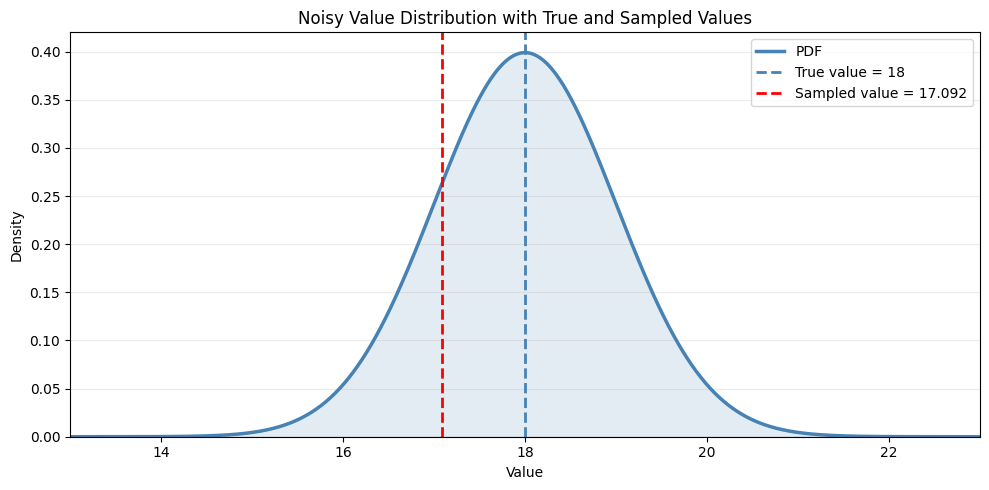

In [61]:
nd = NormalDist(mu=true_value, sigma=sigma)
x = np.linspace(true_value - 5 * sigma, true_value + 5 * sigma, 1000)
owner_pdf = np.array([nd.pdf(v) for v in x])

plt.figure(figsize=(10, 5))
plt.plot(x, owner_pdf, color='steelblue', linewidth=2.5, label='PDF')
plt.fill_between(x, owner_pdf, color='steelblue', alpha=0.15)
plt.axvline(true_value, color='steelblue', linestyle='--', linewidth=2, label=f'True value = {true_value:g}')
plt.axvline(sampled_value, color='red', linestyle='--', linewidth=2, label=f'Sampled value = {sampled_value:.3f}')
plt.xlim(13, 23)
plt.ylim(0, 0.42)
plt.title('Noisy Value Distribution with True and Sampled Values')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

The data owner publishes the data and the noise distribution used to privatize it. An analyst is interested in the noisy value. But how much to trust it?

If only the analyst had the PDF, they could explore how reliable their findings are! They can't have the PDF (in fact the PDF reveals the true value), but perhaps they can approximate. The analyst knows the noise distribution, just not where to put it. Try centering it on the noisy value? Near-zero noise values are more likely than large noise values, after all.

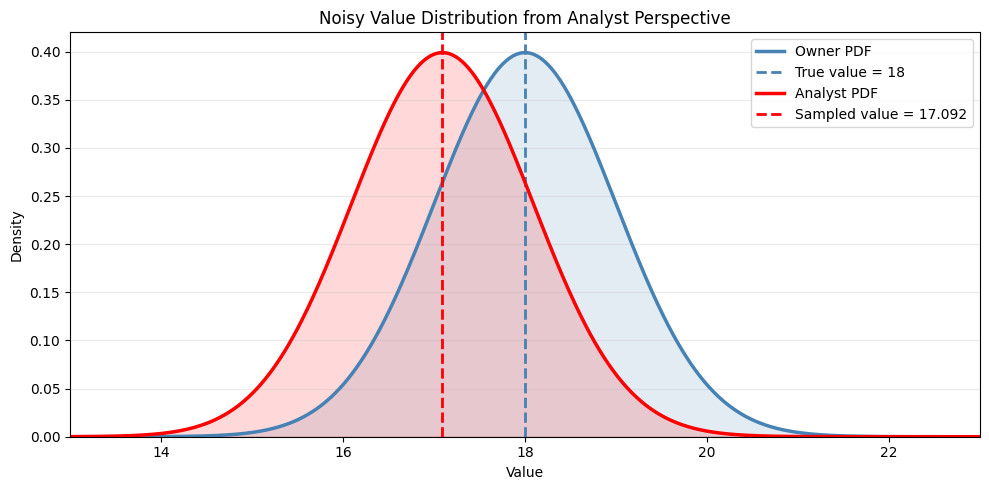

In [62]:
nd = NormalDist(mu=sampled_value, sigma=sigma)
analyst_pdf = np.array([nd.pdf(v) for v in x])

plt.figure(figsize=(10, 5))
plt.plot(x, owner_pdf, color='steelblue', linewidth=2.5, label='Owner PDF')
plt.fill_between(x, owner_pdf, color='steelblue', alpha=0.15)
plt.axvline(true_value, color='steelblue', linestyle='--', linewidth=2, label=f'True value = {true_value:g}')
plt.plot(x, analyst_pdf, color='red', linewidth=2.5, label='Analyst PDF')
plt.fill_between(x, analyst_pdf, color='red', alpha=0.15)
plt.axvline(sampled_value, color='red', linestyle='--', linewidth=2, label=f'Sampled value = {sampled_value:.3f}')
plt.xlim(13, 23)
plt.ylim(0, 0.42)
plt.title('Noisy Value Distribution from Analyst Perspective')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

It's about calculating a _posterior_ distribution. The posterior is based on incomplete information, and so it's not accurate. But it answers the question, what should the analyst believe about the true value given the sampled value and noise distribution?

Calculating the posterior gets complicated as the analyst introduces more variables and starts combining them.